# week4 提出課題

## 課題の要約

第4章のスター付き課題として、美しいライフゲームのアニメーションをPythonで実装する。マットプロットリブの標準的な `cmap` に頼らず、自前の色設計で表示する。今回は mp4 の保存は行わず、アニメーションを生成できる実装までを提出対象とする。

## 実装方針

ライフゲームの更新規則を `next_cell_living` と `next_field` に分け、表示側は `field_to_rgba` で RGBA 配列に変換する。生存セルは経過世代に応じて暖色系のグラデーションにし、背景は濃い色に固定して見やすさを確保した。アニメーションは `FuncAnimation` で作成する（第4章 4.4「有限ライフゲーム」, p.73-78; 第4章 4.5「この章の提出課題」, p.79）。

In [1]:
from importlib.util import module_from_spec, spec_from_file_location
from pathlib import Path

spec = spec_from_file_location('ch04_answer', Path('..') / 'outputs' / 'ch04' / 'answer.py')
ch04_answer = module_from_spec(spec)
assert spec is not None and spec.loader is not None
spec.loader.exec_module(ch04_answer)

next_field = ch04_answer.next_field
make_field = ch04_answer.make_field
glider = ch04_answer.glider
show_color_animation = ch04_answer.show_color_animation
field_to_rgba = ch04_answer.field_to_rgba

def test_next_field():
    a = [
        [False, True, False, False, False],
        [False, False, True, False, False],
        [True, True, True, False, False],
        [False, False, False, False, False],
        [False, False, False, False, False],
    ]
    expected = [
        [False, False, False, False, False],
        [True, False, True, False, False],
        [False, True, True, False, False],
        [False, True, False, False, False],
        [False, False, False, False, False],
    ]
    assert next_field(a) == expected

test_next_field()
print('next_field test passed')

next_field test passed


rgba shape = (15, 15, 4)
animation type = FuncAnimation


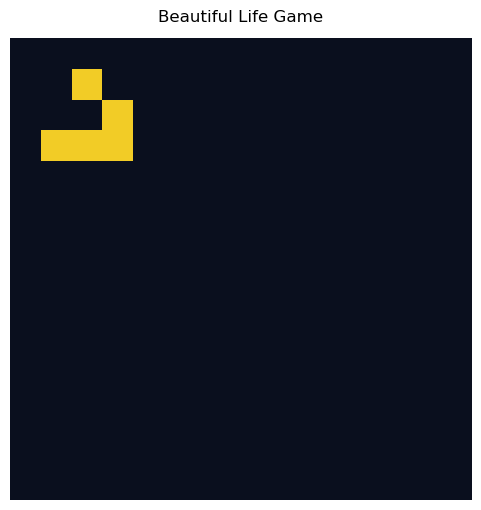

In [2]:
field = make_field(15, 15, glider(1, 1))
rgba = field_to_rgba(field, 0)
anim = show_color_animation(field, step=50)

print('rgba shape =', rgba.shape)
print('animation type =', type(anim).__name__)
assert rgba.shape == (15, 15, 4)
assert type(anim).__name__ == 'FuncAnimation'

## 実行結果

`next_field` のテストが通り、`FuncAnimation` のオブジェクトを生成できることを確認した。表示は自前の色指定を使い、ライフゲームの進行が見やすいようにした。

## 確認

`outputs/ch04/answer.py` を `uv run python` で実行し、`nbconvert --execute` でもセル順に正常終了することを確認する。今回の提出では mp4 保存は行わず、アニメーション生成までを実装対象とした。

## 作業ログ

- 第4章の提出課題を確認した。
- スター付き課題として美しいライフゲームのアニメーションを実装した。
- `outputs/ch04/answer.py` を作成した。
- `uv run python outputs/ch04/answer.py` で実行確認した。
- `notebooks/week4-08252018.ipynb` を作成した。
- notebook の実行確認を行う予定で、必要なら依存を追加した。